# Results

## Librairies

In [132]:
import os
import ast

import re
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Read results

In [133]:
results_folder = "."
file_name = f"results_0_all_testsubset_[1]_p=0.7_nlp.csv"

In [134]:
match = re.search(r"results_(\d+).*?\[(\d+)\]_p=([\d.]+)", file_name)
if match:
    c = int(match.group(2))  # 1
    p = float(match.group(3))           # 0.7
c, p

(1, 0.7)

In [135]:
results_df = pd.read_csv(file_name)
results_df = results_df.sort_values(by="error_polytope")
results_df = results_df.reset_index(drop=True) # reset index

In [136]:
results_df

,error_x0_a,error_x0_b,error_x0_c,error_polytope,net_prob_x0,net_class_x0,net_approx_prob_x0,net_approx_class_x0,net_prob_x_opt,net_class_x_opt,net_logits_x_opt,net_approx_prob_x_opt,net_approx_class_x_opt,net_approx_logits_x_opt
0,2.700000e-07,2.700000e-07,2.700000e-07,2.700000e-07,1.000000,1,1.000000,1,1.000000,1,"[2.0627123608299494e-17, 0.999999988417818, 1....",1.000000,1,"[1.3675452822721585e-19, 0.9999999918041041, 3..."
1,4.700000e-07,4.700000e-07,4.700000e-07,4.700000e-07,1.000000,1,1.000000,1,1.000000,1,"[1.223442614359509e-16, 0.9999999816515416, 1....",1.000000,1,"[4.000098719035249e-20, 0.9999999978895802, 1...."
2,6.300000e-07,6.300000e-07,6.300000e-07,6.300000e-07,1.000000,1,1.000000,1,1.000000,1,"[4.698822791526766e-15, 0.9999999738494769, 3....",1.000000,1,"[1.761247970173595e-17, 0.9999999995113875, 3...."
3,7.000000e-07,7.000000e-07,7.000000e-07,7.000000e-07,1.000000,1,1.000000,1,1.000000,1,"[1.403690819647794e-14, 0.9999999673528441, 2....",1.000000,1,"[7.3554302313824e-17, 0.9999999979023921, 3.90..."
4,7.300000e-07,7.300000e-07,7.300000e-07,7.300000e-07,1.000000,1,1.000000,1,1.000000,1,"[1.0439686952335724e-15, 0.999999963623964, 6....",1.000000,1,"[1.79319670000824e-18, 0.9999999702492204, 2.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1124,3.534440e-03,3.534440e-03,3.534440e-03,1.709608e+01,0.999743,1,0.999982,1,0.993020,7,"[3.6152647841055505e-08, 0.0026386000348917605...",0.999902,7,"[4.088081224741777e-09, 9.080536008063891e-05,..."
1125,5.207000e-05,5.207000e-05,5.207000e-05,2.216487e+01,0.999997,1,0.999985,1,0.519958,3,"[1.0856378502033556e-05, 0.006992495750589856,...",0.993303,7,"[1.553858108248952e-07, 0.00031211705656884823..."
1126,2.788668e-02,2.788668e-02,2.788668e-02,2.490525e+01,0.996320,1,0.992485,1,0.610197,1,"[1.1841966739970808e-10, 0.6101970963923308, 0...",0.999417,7,"[2.3383648851652197e-15, 0.0005328272218702282..."
1127,8.846000e-05,8.846000e-05,8.846000e-05,2.779951e+01,0.999996,1,0.999949,1,0.999643,3,"[1.4897224212265697e-13, 0.0003574178833903417...",1.000000,3,"[2.2794503246578394e-16, 3.588144415617217e-08..."


In [137]:
results_df.columns

Index(['error_x0_a', 'error_x0_b', 'error_x0_c', 'error_polytope',
       'net_prob_x0', 'net_class_x0', 'net_approx_prob_x0',
       'net_approx_class_x0', 'net_prob_x_opt', 'net_class_x_opt',
       'net_logits_x_opt', 'net_approx_prob_x_opt', 'net_approx_class_x_opt',
       'net_approx_logits_x_opt'],
      dtype='object')

## Sanity checks

In [138]:
# === Sanity check 1 === #
# 3 errors at x_0 coincide

tolerance = 1e-6

# 3 errors coincide
mask_1 = ((results_df['error_x0_a'] - results_df['error_x0_b']).abs() < tolerance).all()
mask_2 = ((results_df['error_x0_b'] - results_df['error_x0_c']).abs() < tolerance).all()
mask_3 = ((results_df['error_x0_c'] - results_df['error_x0_a']).abs() < tolerance).all()

mask = (mask_1 and mask_2 and mask_3).item()

print("SANITY CHECK:\t 3 types of errors at x0 coincide")
print(f"{mask}")


SANITY CHECK:	 3 types of errors at x0 coincide
True


In [139]:
# === Sanity check 2 === #
# x_0 always predicted correctly by N with prob ≥ p

mask_1 = (results_df['net_class_x0'] == c)    # x_0 correcly predicted
mask_2 = (results_df['net_prob_x0'] >= p)     # x_0 predicted with prob ≥ p
mask = mask_1 & mask_2

print("SANITY CHECK:\t N(x_0) = c and prob[N(x_0)] ≥ p")
print(f"{np.sum(mask) / len(results_df) * 100}%")

SANITY CHECK:	 N(x_0) = c and prob[N(x_0)] ≥ p
100.0%


### Remove wrong/non-converging samples

1. Samples such that $\mathcal{N}(x_{opt}) \neq c$
2. Samples such that $p [ \mathcal{N}(x_{opt}) ] < p$
2. Samples such that $Error(x_{opt}) \leq Error(x_0)$

In [140]:
# === Filter 1 ==== #
# Remvoe samples such that $\mathcal{N}(x_{opt}) \neq c$
# NOTE: that these samples are at the end of the dataset since 
# they are the ones requiring the most computation...

mask = results_df.net_class_x_opt != c
indices = mask[mask].index

print(f"There are {len(indices)} samples such that N(x_opt) ≠ c at indices:\n{list(indices)}")

results_df = results_df.drop(indices)
results_df = results_df.reset_index(drop=True) # important


There are 53 samples such that N(x_opt) ≠ c at indices:
[622, 653, 654, 662, 666, 674, 687, 698, 707, 716, 722, 724, 756, 778, 781, 783, 784, 790, 810, 811, 813, 818, 829, 840, 844, 847, 849, 850, 851, 875, 889, 890, 898, 900, 915, 927, 955, 968, 970, 973, 993, 1004, 1019, 1028, 1042, 1045, 1063, 1109, 1122, 1124, 1125, 1127, 1128]


In [141]:
# === Filter 2 ==== #
# Remvoe samples such that $p[ \mathcal{N}(x_{opt}) ] < p$

mask = results_df.net_prob_x_opt < p
indices = mask[mask].index

print(f"There are {len(indices)} samples such that p[N(x_opt)] < p at indices:\n{list(indices)}")

results_df = results_df.drop(indices)
results_df = results_df.reset_index(drop=True) # important

There are 43 samples such that p[N(x_opt)] < p at indices:
[616, 619, 627, 639, 640, 653, 655, 664, 671, 677, 686, 689, 692, 709, 711, 715, 731, 736, 745, 750, 765, 778, 788, 792, 803, 812, 831, 838, 843, 852, 861, 887, 888, 889, 896, 919, 937, 946, 951, 986, 991, 1027, 1075]


In [122]:
# === Filter 3 ==== #
# Samples such that $Error(x_{opt}) < Error(x_0)$
# error at x_opt points cannot be smaller than error at x_0...

errors_samples = results_df['error_x0_a']
errors_polytopes = results_df['error_polytope']

mask = errors_polytopes - errors_samples < 0
indices = mask[mask].index

print(f"There are {len(indices)} samples such that Error(x_opt) < Error(x_0) at indices:\n{list(indices)}")

results_df = results_df.drop(indices)
results_df = results_df.reset_index(drop=True) # important

There are 0 samples such that Error(x_opt) < Error(x_0) at indices:
[]


In [146]:
# === Filter 3 ==== #
# Samples such that $Error(x_{opt}) = Error(x_0)$
# For these samples, the algorithm probably failed to converge,
# as error at x_opt points equals the error at x_0...

errors_samples = results_df['error_x0_a']
errors_polytopes = results_df['error_polytope']

mask = errors_polytopes == errors_samples
indices = mask[mask].index

print(f"There are {len(indices)} samples such that Error(x_opt) = Error(x_0) at indices:\n{list(indices)}")
print("For these samples, the algorithm probably failed to converge, as error at x_opt points equals the error at x_0...")
print("Samples not removed...")

There are 615 samples such that Error(x_opt) = Error(x_0) at indices:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207,

In [148]:
# === Sanity check ===

print(
    results_df.shape[0],
    np.sum(results_df.net_prob_x0 >= p).item(),
    np.sum(results_df.net_class_x0 == 1).item(),
    np.sum(results_df.net_class_x_opt == 1).item(),
    np.sum(results_df.error_polytope - results_df.error_x0_a >= 0).item()
)

1033 1033 1033 1033 1033


## Results

### Errors at x0 and x_opt

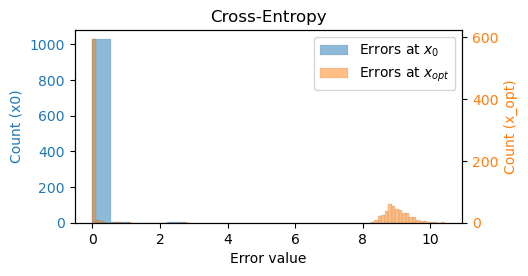

In [149]:
errors_x0 = list(results_df.error_x0_a.values)
errors_x_opt = list(results_df.error_polytope.values)

fig, ax1 = plt.subplots(figsize=(5, 2.5))
ax2 = ax1.twinx()  # second y-axis

# first histogram on ax1
ax1.hist(errors_x0, bins=5, alpha=0.5, edgecolor="black", linewidth=0.1, color="C0", label=r"Errors at $x_0$")
ax1.set_ylabel("Count (x0)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")

# second histogram on ax2
ax2.hist(errors_x_opt, bins=100, alpha=0.5, edgecolor="black", linewidth=0.1, color="C1", label=r"Errors at $x_{opt}$")
ax2.set_ylabel("Count (x_opt)", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

# shared x-axis
ax1.set_xlabel("Error value")
plt.title(r"Cross-Entropy")

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.savefig(f"erors_c={c}_p={p}.pdf", bbox_inches="tight")
plt.show()

### Misclassified polytopes

In [152]:
# We detect Ñ(x_opt) ≠ N(x_opt)
net_class_x_opt = results_df.net_class_x_opt
net_approx_class_x_opt = results_df.net_approx_class_x_opt

mis_idx = np.where(net_class_x_opt != net_approx_class_x_opt)[0]

print(f"There are {len(mis_idx)} misclassified polytopes at indices:\n{mis_idx}")

There are 1 misclassified polytopes at indices:
[613]


In [153]:
mis_df = results_df.iloc[mis_idx]

In [154]:
# mis_df

1 1 1 1


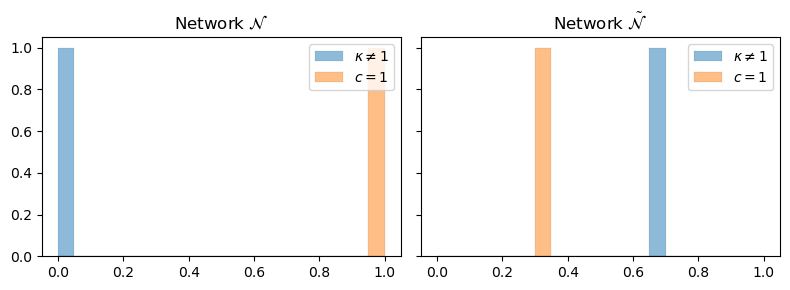

In [155]:
net_logits_x_opt = mis_df.net_logits_x_opt.apply(ast.literal_eval)
net_logits_x_opt = list(net_logits_x_opt.values)

net_class_x_opt = mis_df.net_class_x_opt
net_class_x_opt = list(map(int, net_class_x_opt))
# net_class_x_opt = list(net_class_x_opt.values)

net_approx_logits_x_opt = mis_df.net_approx_logits_x_opt.apply(ast.literal_eval)
net_approx_logits_x_opt = list(net_approx_logits_x_opt.values)

net_approx_class_x_opt =  mis_df.net_approx_class_x_opt
net_approx_class_x_opt = list(map(int, net_approx_class_x_opt))
#net_approx_class_x_opt = list(net_approx_class_x_opt.values)

# sanity check
assert (net_class_x_opt != net_approx_class_x_opt) == True

net_probs_c = [logits[c] for logits, c in zip(net_logits_x_opt, net_class_x_opt)]
net_probs_kappa = [logits[k] for logits, k in zip(net_logits_x_opt, net_approx_class_x_opt)]

net_approx_probs_c = [logits[c] for logits, c in zip(net_approx_logits_x_opt, net_class_x_opt)]
net_approx_probs_kappa = [logits[k] for logits, k in zip(net_approx_logits_x_opt, net_approx_class_x_opt)]

print(
    len(net_probs_c),
    len(net_probs_c),
    len(net_approx_probs_c),
    len(net_approx_probs_kappa)
    )

bins = np.linspace(0, 1, 21)  # 20 equal-width bins from 0 to 1

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)  # 1 row, 2 cols

# --- Left plot ---
axes[0].set_title(r"Network $\mathcal{N}$")
axes[0].hist(net_probs_kappa, bins=bins, label=rf"$\kappa \neq {c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[0].hist(net_probs_c, bins=bins, label=rf"$c={c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[0].legend(loc="upper right")

# --- Right plot ---
axes[1].set_title(r"Network $\mathcal{\tilde N}$")
axes[1].hist(net_approx_probs_kappa, bins=bins, label=rf"$\kappa \neq {c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[1].hist(net_approx_probs_c, bins=bins, label=rf"$c={c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"misclassified_polytopes_c={c}_p={p}.pdf", bbox_inches="tight")
plt.show()


In [156]:
net_class_x_opt, net_approx_class_x_opt

([1], [2])